# Aplicação de um SIN para controle de central de reparo de peças.

O problema é desenvolver e implementar um SIN para gerenciar uma central de reparo e distribuição de peças, de forma a reduzir o tempo de espera pelo serviço.


In [45]:
%%html
<style>
  table > caption,
  table > tbody > tr > th {
    font-weight: bold;
  }
</style>


In [46]:
import numpy as np
import skfuzzy as fuzzy
from babel.numbers import format_decimal as decimal
from IPython.display import HTML, display
from skfuzzy import control as ctrl

## Modelagem do problema

A modelagem nebulosa do problema real compreende:

1.  definir o contexto e a questão a ser tratada. I.e., definir o problema que se quer resolver, a pergunta que se quer responder ou a decisão a ser tomada. Ainda, definir qual o contexto da questão, ou seja, definir os atores e sob quais circunstâncias, aspectos e negócio a questão está sendo percebida;

2.  definir qual a variável linguística de saída que será o resultado, resposta ou decisão da questão a ser tratada;

3.  definir os termos linguísticos (conjuntos nebulosos) da variável de saída. I.e., os possíveis valores que a variável de saída pode assumir;

4.  definir a representação dos conjuntos nebulosos da variável de saída. I.e., em geral, definir se a representação será por função de pertinência ou explícita (p. ex., listando os elementos do conjunto nebuloso em uma tabela);

5.  definir as variáveis linguísticas de entrada;

6.  definir os termos linguísticos (conjuntos nebulosos) de cada variável de entrada. I.e., os possíveis valores que as variáveis de entrada podem assumir;

7.  definir a representação dos conjuntos nebulosos das variáveis de entrada. I.e., em geral, definir se a representação será por função de pertinência ou explícita (p. ex., listando os elementos do conjunto nebuloso em uma tabela);

8.  definir as regras de inferência;

9.  definir o método de inferência que, na maioria das vezes, poderá ser Mandani ou Larsen. Mas, podem ser usado outros métodos, dependendo do problema em questão;

10. definir o método de defuzzificação.


## Definição do problema


### Contexto

- **Objetivo:** Aplicação de um SIN para estabelecer um estoque adequado para reduzir o tempo de atendimento em uma central de peças.
- **Pergunta:** Qual é o estoque de peças em perfeito estado necessário?
- **Atores:** Cliente que leva a peça para ser reparada e que deseja uma peça reparada, gerente da loja que gerencia a alocação de recursos.
- **Circunstâncias:** O usuário chega à loja com uma peça com defeito, e solicita que ela seja trocada por uma peça nova. O cliente deve receber uma peça em perfeito estado do estoque. Aquela com defeito deve ser reparada e colocada no estoque.
- **Aspectos:** Deve-se analisar o estoque ideal para diferentes exigências de celeridade no atendimento.


### Saída

#### Estoque (`N`)

Quantidade de peças em **estoque** necessária para entregar ao cliente.

- Dado entre 0 e 20 minutos.
- Normalizado entre 0.0 e 1.0.

Termos linguísticos:

- Muito pequeno (`MP`): [0, 4] &mdash; [0.0, 0.2].
- Pequeno (`P`): ]4, 6] &mdash; ]0.2, 0.3].
- Razoavelmente pequeno (`RP`): ]6, 8] &mdash; ]0.3, 0.4].
- Médio (`M`): ]8, 12] &mdash; ]0.4, 0.6].
- Razoavelmente grande (`RG`): ]12, 14] &mdash; ]0.6, 0.7].
- Grande (`G`): ]14, 16] &mdash; ]0.7, 0.8].
- Muito grande (`MG`): ]16, 20] &mdash; ]0.8, 1.0].

Representação:

- Funções de pertinência:
  - trapezoidais para os termos `MP` e `MG`;
  - triangulares para demais termos.


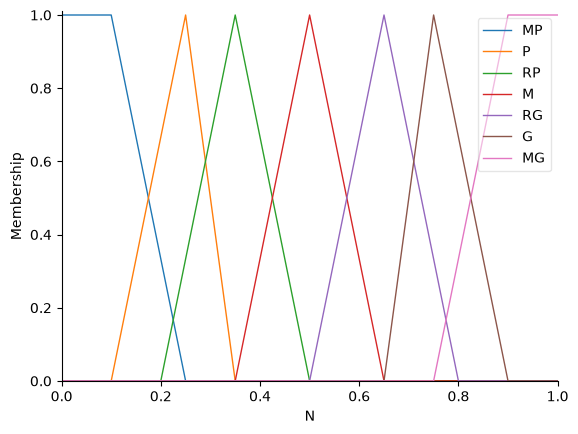

In [47]:
# Define o universo de valores.
stock_universe = np.arange(0, 1.05, 0.05)

# Define a variável.
stock_variable = ctrl.Consequent(stock_universe, "N")

# Define as funções de pertinência.
stock_variable["MP"] = fuzzy.trapmf(stock_variable.universe, [0.0, 0.0, 0.1, 0.25])
stock_variable["P"] = fuzzy.trimf(stock_variable.universe, [0.1, 0.25, 0.35])
stock_variable["RP"] = fuzzy.trimf(stock_variable.universe, [0.2, 0.35, 0.5])
stock_variable["M"] = fuzzy.trimf(stock_variable.universe, [0.35, 0.5, 0.65])
stock_variable["RG"] = fuzzy.trimf(stock_variable.universe, [0.5, 0.65, 0.8])
stock_variable["G"] = fuzzy.trimf(stock_variable.universe, [0.65, 0.75, 0.9])
stock_variable["MG"] = fuzzy.trapmf(stock_variable.universe, [0.75, 0.9, 1.0, 1.0])

stock_variable.view()

# Checagem de cobertura.
stock_coverage = np.maximum.reduce(
    [
        stock_variable["MP"].mf,
        stock_variable["P"].mf,
        stock_variable["RP"].mf,
        stock_variable["M"].mf,
        stock_variable["RG"].mf,
        stock_variable["G"].mf,
        stock_variable["MG"].mf,
    ]
)
display(HTML(f"Valores sem cobertura: {stock_universe[stock_coverage == 0]}"))


### Entrada


#### Tempo de espera (`M`)

Tempo de **espera** médio do cliente para receber uma peça nova.

- Dado em minutos.
- Normalizado entre 0.0 e 1.0.

Termos linguísticos:

- Muito pequeno (`MP`): [0.0, 0.2].
- Pequeno (`P`): ]0.2, 0.4].
- Médio (`M`): ]0.4, 0.6].

Representação:

- Funções de pertinência:
  - trapezoidais para os termos `MP` e `M`;
  - triangular para o termo `P`.


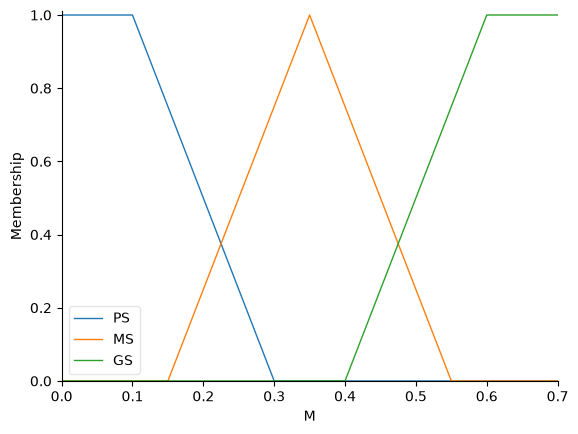

In [48]:
# Define o universo de valores.
wait_universe = np.arange(0, 0.75, 0.05)

# Define a variável.
wait_variable = ctrl.Antecedent(wait_universe, "M")

# Define as funções de pertinência.
wait_variable["PS"] = fuzzy.trapmf(wait_universe, [0.0, 0.0, 0.1, 0.3])
wait_variable["MS"] = fuzzy.trimf(wait_universe, [0.15, 0.35, 0.55])
wait_variable["GS"] = fuzzy.trapmf(wait_universe, [0.4, 0.6, 0.7, 0.75])

wait_variable.view()

# Checagem de cobertura.
wait_coverage = np.maximum.reduce(
    [
        wait_variable["PS"].mf,
        wait_variable["MS"].mf,
        wait_variable["GS"].mf,
    ]
)
display(HTML(f"Valores sem cobertura: {wait_universe[wait_coverage == 0]}"))


#### Quantidade de funcionários (`S`)

Quantidade de **funcionários** disponíveis.

- Dado entre 2 e 20.
- Normalizado entre 0.0 e 1.0.

Termos linguísticos:

- Muito pequeno (`MP`): [2, 3] &mdash; [0.1, 0.15].
- Pequeno (`P`): ]3, 5] &mdash; ]0.15, 0.25].
- Razoavelmente pequeno (`RP`): ]5, 8] &mdash; ]0.25, 0.4].
- Médio (`M`): ]8, 12] &mdash; ]0.4, 0.6].
- Razoavelmente grande (`RG`): ]12, 14] &mdash; ]0.6, 0.7].
- Grande (`G`): ]14, 16] &mdash; ]0.7, 0.8].
- Muito grande (`MG`): ]16, 20] &mdash; ]0.8, 1.0].

Representação:

- Funções de pertinência:
  - linear para o termo `MP`;
  - trapezoidal para os termo `RP` e `MG`;
  - triangulares para demais termos.


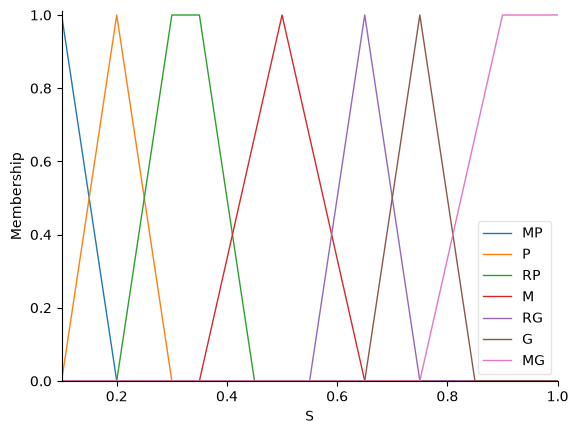

In [49]:
# Define o universo de valores.
employees_universe = np.arange(0.1, 1.05, 0.05)

# Define a variável.
employees_variable = ctrl.Antecedent(employees_universe, "S")

# Define as funções de pertinência.
employees_variable["MP"] = fuzzy.trimf(employees_variable.universe, [0.10, 0.10, 0.20])
employees_variable["P"] = fuzzy.trimf(employees_variable.universe, [0.10, 0.20, 0.30])
employees_variable["RP"] = fuzzy.trapmf(
    employees_variable.universe, [0.20, 0.30, 0.35, 0.45]
)
employees_variable["M"] = fuzzy.trimf(employees_variable.universe, [0.35, 0.5, 0.65])
employees_variable["RG"] = fuzzy.trimf(employees_variable.universe, [0.55, 0.65, 0.75])
employees_variable["G"] = fuzzy.trimf(employees_variable.universe, [0.65, 0.75, 0.85])

employees_variable["MG"] = fuzzy.trapmf(
    employees_variable.universe, [0.75, 0.9, 1.0, 1.05]
)

employees_variable.view()

# Checagem de cobertura.
employees_coverage = np.maximum.reduce(
    [
        employees_variable["MP"].mf,
        employees_variable["P"].mf,
        employees_variable["RP"].mf,
        employees_variable["M"].mf,
        employees_variable["RG"].mf,
        employees_variable["G"].mf,
        employees_variable["MG"].mf,
    ]
)
display(HTML(f"Valores sem cobertura: {employees_universe[employees_coverage == 0]}"))

#### Fator de uso (`P`)

Fator de **uso** da central de reparos.

- Dado em porcentagem.
- Normalizado entre 0.0 e 1.0.

Termos linguísticos:

- Baixo (`B`).
- Médio (`M`).
- Alto (`A`).
- Muito alto (`MA`).

Representação:

- Funções de pertinência:
  - distribuição de Poisson.


In [50]:
seed = np.random.seed(27)
quantity_of_samples = 100

# Taxa de chegada de peças — Número médio de clientes por unidade de tempo.
arrival_rate = 4

sample = np.random.poisson(lam=arrival_rate, size=quantity_of_samples)
normalized_sample = sample / sample.max()

display(sample)
display(normalized_sample)

array([ 7,  7,  3,  3,  2,  5,  5,  3,  0,  8,  6,  7,  5,  2,  2,  5,  2,
        3,  8,  5,  5,  4,  3,  2,  6,  1,  6,  5,  4,  4,  9,  2,  2,  4,
        5,  2,  9,  1,  7,  3,  2,  2,  4,  4,  9,  2,  3,  5,  3,  3,  3,
        0,  6,  6,  3,  9,  4,  5,  1,  5,  1,  5,  1,  3,  2, 13,  2,  6,
        6,  3,  6,  6,  1,  5,  2,  4,  3,  4,  5,  3,  4,  6,  4,  2,  3,
        2,  3,  3,  3,  1,  3,  6,  2,  3,  5,  3,  1,  4,  5,  4])

array([0.53846154, 0.53846154, 0.23076923, 0.23076923, 0.15384615,
       0.38461538, 0.38461538, 0.23076923, 0.        , 0.61538462,
       0.46153846, 0.53846154, 0.38461538, 0.15384615, 0.15384615,
       0.38461538, 0.15384615, 0.23076923, 0.61538462, 0.38461538,
       0.38461538, 0.30769231, 0.23076923, 0.15384615, 0.46153846,
       0.07692308, 0.46153846, 0.38461538, 0.30769231, 0.30769231,
       0.69230769, 0.15384615, 0.15384615, 0.30769231, 0.38461538,
       0.15384615, 0.69230769, 0.07692308, 0.53846154, 0.23076923,
       0.15384615, 0.15384615, 0.30769231, 0.30769231, 0.69230769,
       0.15384615, 0.23076923, 0.38461538, 0.23076923, 0.23076923,
       0.23076923, 0.        , 0.46153846, 0.46153846, 0.23076923,
       0.69230769, 0.30769231, 0.38461538, 0.07692308, 0.38461538,
       0.07692308, 0.38461538, 0.07692308, 0.23076923, 0.15384615,
       1.        , 0.15384615, 0.46153846, 0.46153846, 0.23076923,
       0.46153846, 0.46153846, 0.07692308, 0.38461538, 0.15384

## Criação de regras de inferência


### Matrizes associativas fuzzy

#### Quantidade: Pouca (`PQ`)

**Sujeira / Manchas**

|        |  PM |  MM |  GM |
| ------ | --: | --: | --: |
| **PS** |  MC |  MC |   C |
| **MS** |  MC |   C |   C |
| **GS** |   C |   C |   M |

#### Quantidade: Média (`MQ`)

**Sujeira / Manchas**

|        |  PM |  MM |  GM |
| ------ | --: | --: | --: |
| **PS** |   C |   C |   M |
| **MS** |   C |   M |   M |
| **GS** |   M |   M |   L |

#### Quantidade: Grande (`GQ`)

**Sujeira / Manchas**

|        |  PM |  MM |  GM |
| ------ | --: | --: | --: |
| **PS** |   M |   M |   L |
| **MS** |   M |   L |   L |
| **GS** |   L |   L |  ML |

#### Quantidade: Muito grande (`MGQ`)

**Sujeira / Manchas**

|        |  PM |  MM |  GM |
| ------ | --: | --: | --: |
| **PS** |   L |   L |  ML |
| **MS** |   L |  ML |  ML |
| **GS** |  ML |  ML |  ML |


### Definição das regras


In [51]:
# Quantidade: Pouca (PQ)

r1 = ctrl.Rule(
    dirtiness_variable["PS"] & stains_variable["PM"] & quantity_variable["PQ"],
    duration_variable["MC"],
)
r2 = ctrl.Rule(
    dirtiness_variable["PS"] & stains_variable["MM"] & quantity_variable["PQ"],
    duration_variable["MC"],
)
r3 = ctrl.Rule(
    dirtiness_variable["PS"] & stains_variable["GM"] & quantity_variable["PQ"],
    duration_variable["C"],
)
r4 = ctrl.Rule(
    dirtiness_variable["MS"] & stains_variable["PM"] & quantity_variable["PQ"],
    duration_variable["MC"],
)
r5 = ctrl.Rule(
    dirtiness_variable["MS"] & stains_variable["MM"] & quantity_variable["PQ"],
    duration_variable["C"],
)
r6 = ctrl.Rule(
    dirtiness_variable["MS"] & stains_variable["GM"] & quantity_variable["PQ"],
    duration_variable["C"],
)
r7 = ctrl.Rule(
    dirtiness_variable["GS"] & stains_variable["PM"] & quantity_variable["PQ"],
    duration_variable["C"],
)
r8 = ctrl.Rule(
    dirtiness_variable["GS"] & stains_variable["MM"] & quantity_variable["PQ"],
    duration_variable["C"],
)
r9 = ctrl.Rule(
    dirtiness_variable["GS"] & stains_variable["GM"] & quantity_variable["PQ"],
    duration_variable["M"],
)

# Quantidade: Média (MQ)

r10 = ctrl.Rule(
    dirtiness_variable["PS"] & stains_variable["PM"] & quantity_variable["MQ"],
    duration_variable["C"],
)
r11 = ctrl.Rule(
    dirtiness_variable["PS"] & stains_variable["MM"] & quantity_variable["MQ"],
    duration_variable["C"],
)
r12 = ctrl.Rule(
    dirtiness_variable["PS"] & stains_variable["GM"] & quantity_variable["MQ"],
    duration_variable["M"],
)
r13 = ctrl.Rule(
    dirtiness_variable["MS"] & stains_variable["PM"] & quantity_variable["MQ"],
    duration_variable["C"],
)
r14 = ctrl.Rule(
    dirtiness_variable["MS"] & stains_variable["MM"] & quantity_variable["MQ"],
    duration_variable["M"],
)
r15 = ctrl.Rule(
    dirtiness_variable["MS"] & stains_variable["GM"] & quantity_variable["MQ"],
    duration_variable["M"],
)
r16 = ctrl.Rule(
    dirtiness_variable["GS"] & stains_variable["PM"] & quantity_variable["MQ"],
    duration_variable["M"],
)
r17 = ctrl.Rule(
    dirtiness_variable["GS"] & stains_variable["MM"] & quantity_variable["MQ"],
    duration_variable["M"],
)
r18 = ctrl.Rule(
    dirtiness_variable["GS"] & stains_variable["GM"] & quantity_variable["MQ"],
    duration_variable["L"],
)

# Quantidade: Grande (GQ)

r19 = ctrl.Rule(
    dirtiness_variable["PS"] & stains_variable["PM"] & quantity_variable["GQ"],
    duration_variable["M"],
)
r20 = ctrl.Rule(
    dirtiness_variable["PS"] & stains_variable["MM"] & quantity_variable["GQ"],
    duration_variable["M"],
)
r21 = ctrl.Rule(
    dirtiness_variable["PS"] & stains_variable["GM"] & quantity_variable["GQ"],
    duration_variable["L"],
)
r22 = ctrl.Rule(
    dirtiness_variable["MS"] & stains_variable["PM"] & quantity_variable["GQ"],
    duration_variable["M"],
)
r23 = ctrl.Rule(
    dirtiness_variable["MS"] & stains_variable["MM"] & quantity_variable["GQ"],
    duration_variable["L"],
)
r24 = ctrl.Rule(
    dirtiness_variable["MS"] & stains_variable["GM"] & quantity_variable["GQ"],
    duration_variable["L"],
)
r25 = ctrl.Rule(
    dirtiness_variable["GS"] & stains_variable["PM"] & quantity_variable["GQ"],
    duration_variable["L"],
)
r26 = ctrl.Rule(
    dirtiness_variable["GS"] & stains_variable["MM"] & quantity_variable["GQ"],
    duration_variable["L"],
)
r27 = ctrl.Rule(
    dirtiness_variable["GS"] & stains_variable["GM"] & quantity_variable["GQ"],
    duration_variable["ML"],
)

# Quantidade: Muito grande (MGQ)

r28 = ctrl.Rule(
    dirtiness_variable["PS"] & stains_variable["PM"] & quantity_variable["MGQ"],
    duration_variable["L"],
)
r29 = ctrl.Rule(
    dirtiness_variable["PS"] & stains_variable["MM"] & quantity_variable["MGQ"],
    duration_variable["L"],
)
r30 = ctrl.Rule(
    dirtiness_variable["PS"] & stains_variable["GM"] & quantity_variable["MGQ"],
    duration_variable["ML"],
)
r31 = ctrl.Rule(
    dirtiness_variable["MS"] & stains_variable["PM"] & quantity_variable["MGQ"],
    duration_variable["L"],
)
r32 = ctrl.Rule(
    dirtiness_variable["MS"] & stains_variable["MM"] & quantity_variable["MGQ"],
    duration_variable["ML"],
)
r33 = ctrl.Rule(
    dirtiness_variable["MS"] & stains_variable["GM"] & quantity_variable["MGQ"],
    duration_variable["ML"],
)
r34 = ctrl.Rule(
    dirtiness_variable["GS"] & stains_variable["PM"] & quantity_variable["MGQ"],
    duration_variable["ML"],
)
r35 = ctrl.Rule(
    dirtiness_variable["GS"] & stains_variable["MM"] & quantity_variable["MGQ"],
    duration_variable["ML"],
)
r36 = ctrl.Rule(
    dirtiness_variable["GS"] & stains_variable["GM"] & quantity_variable["MGQ"],
    duration_variable["ML"],
)

# Compilação

rules = [
    r1,
    r2,
    r3,
    r4,
    r5,
    r6,
    r7,
    r8,
    r9,
    r10,
    r11,
    r12,
    r13,
    r14,
    r15,
    r16,
    r17,
    r18,
    r19,
    r20,
    r21,
    r22,
    r23,
    r24,
    r25,
    r26,
    r27,
    r28,
    r29,
    r30,
    r31,
    r32,
    r33,
    r34,
    r35,
    r36,
]


NameError: name 'duration_variable' is not defined

## Simulação

### Controle


In [ ]:
### Método de controle


def get_simulation_control(defuzzify_method="centroid"):
    duration_variable.defuzzify_method = defuzzify_method
    duration_ctrl = ctrl.ControlSystem(rules)
    duration_simulation = ctrl.ControlSystemSimulation(duration_ctrl)
    return duration_simulation


def predict_duration(
    dirtiness: int, stains: float, quantity: float, defuzzify_method="centroid"
):
    duration_simulation = get_simulation_control(defuzzify_method=defuzzify_method)
    duration_simulation.input["Grau de sujeira"] = dirtiness
    duration_simulation.input["Grau de manchas"] = stains
    duration_simulation.input["Quantidade de roupas"] = quantity
    duration_simulation.compute()
    return duration_simulation.output["Duração"], duration_simulation


def simulate_and_display(
    dirtiness: int,
    stains: float,
    quantity: float,
    plot_input: bool = False,
    plot_output=False,
    defuzzify_method="centroid",
):
    prediction, duration_simulation = predict_duration(
        dirtiness=dirtiness,
        stains=stains,
        quantity=quantity,
        defuzzify_method=defuzzify_method,
    )
    display(
        HTML(
            f"""<table><caption>Cálculo da duração do ciclo de lavagem.</caption>
                    <thead>
                        <tr>
                            <th>Grau de sujeira (%)</th>
                            <th>Grau de manchas (%)</th>
                            <th>Quantidade de roupas (Kg)</th>
                            <th>Duração (min)</th>
                        </tr>
                    </thead>
                    <tbody>
                        <tr>
                            <td>{decimal(dirtiness, locale="pt_BR")}</td>
                            <td>{decimal(stains, locale="pt_BR")}</td>
                            <td>{decimal(quantity, locale="pt_BR")}</td>
                            <td>{decimal(prediction, locale="pt_BR")}</td>
                    </tbody>
                </table>"""
        )
    )
    if plot_input:
        dirtiness_variable.view(sim=duration_simulation)
        stains_variable.view(sim=duration_simulation)
        quantity_variable.view(sim=duration_simulation)
    if plot_output:
        duration_variable.view(sim=duration_simulation)


def simulate_and_display_many(data, defuzzify_method="centroid"):
    rows = []

    for dirtiness, stains, quantity in data:
        prediction, _ = predict_duration(
            dirtiness=dirtiness,
            stains=stains,
            quantity=quantity,
            defuzzify_method=defuzzify_method,
        )

        rows.append(
            f"""
            <tr>
                <td>{decimal(dirtiness, locale="pt_BR")}</td>
                <td>{decimal(stains, locale="pt_BR")}</td>
                <td>{decimal(quantity, locale="pt_BR")}</td>
                <td>{decimal(prediction, locale="pt_BR")}</td>
            </tr>
            """
        )

    display(
        HTML(
            f"""
            <table>
                <caption>Cálculo da duração do ciclo de lavagem.</caption>
                <thead>
                    <tr>
                        <th>Grau de sujeira (%)</th>
                        <th>Grau de manchas (%)</th>
                        <th>Quantidade de roupas (Kg)</th>
                        <th>Duração (min)</th>
                    </tr>
                </thead>
                <tbody>
                    {"".join(rows)}
                </tbody>
            </table>
            """
        )
    )

In [ ]:
display(HTML("<strong>Método de defuzzificação: centroide</strong>"))
simulate_and_display(dirtiness=50, stains=50, quantity=7, defuzzify_method="centroid")

display(HTML("<strong>Método de defuzzificação: média dos máximos</strong>"))
simulate_and_display(dirtiness=50, stains=50, quantity=7, defuzzify_method="mom")


Grau de sujeira (%),Grau de manchas (%),Quantidade de roupas (Kg),Duração (min)
50,50,7,"34,527"


Grau de sujeira (%),Grau de manchas (%),Quantidade de roupas (Kg),Duração (min)
50,50,7,34


### Método de inferência

Foi decidido utilizar o método de Mamdani, que é o padrão da biblioteca.


Grau de sujeira (%),Grau de manchas (%),Quantidade de roupas (Kg),Duração (min)
50,50,7,"34,527"


Grau de sujeira (%),Grau de manchas (%),Quantidade de roupas (Kg),Duração (min)
50,50,7,34


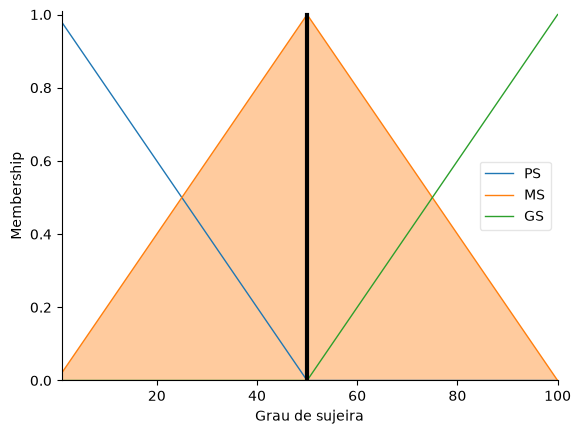

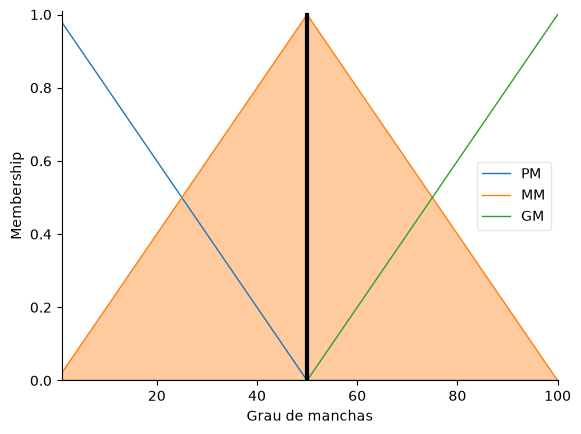

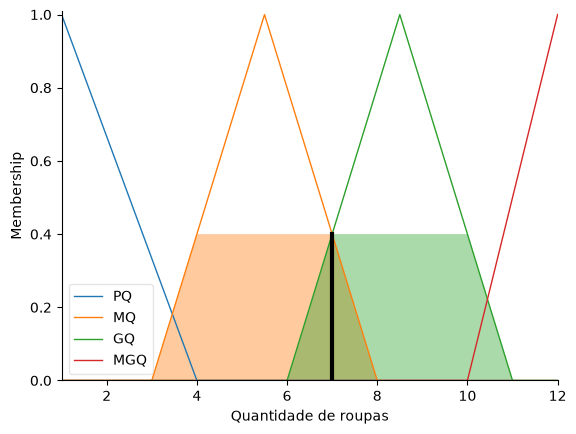

In [ ]:
display(HTML("<strong>Método de defuzzificação: centroide</strong>"))
simulate_and_display(
    dirtiness=50, stains=50, quantity=7, plot_input=True, defuzzify_method="centroid"
)

display(HTML("<strong>Método de defuzzificação: média dos máximos</strong>"))
simulate_and_display(dirtiness=50, stains=50, quantity=7, defuzzify_method="mom")


### Defuzzificação

Foi decidido utilizar os métodos de Centroide e de Média dos máximos.


Grau de sujeira (%),Grau de manchas (%),Quantidade de roupas (Kg),Duração (min)
50,50,7,"34,527"


Grau de sujeira (%),Grau de manchas (%),Quantidade de roupas (Kg),Duração (min)
50,50,7,34


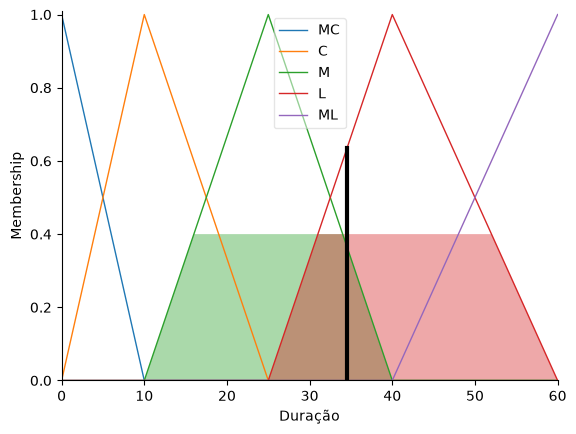

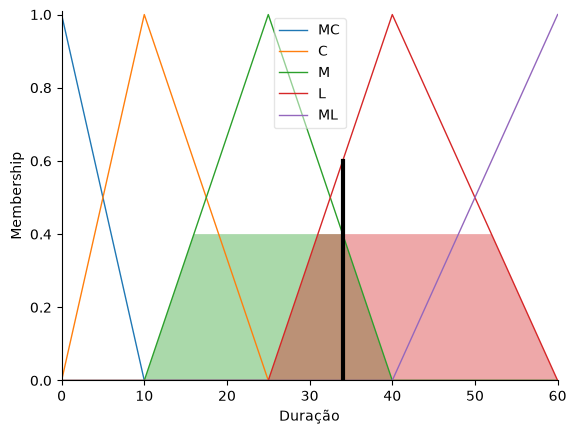

In [ ]:
display(HTML("<strong>Método de defuzzificação: centroide</strong>"))
simulate_and_display(
    dirtiness=50, stains=50, quantity=7, defuzzify_method="centroid", plot_output=True
)

display(HTML("<strong>Método de defuzzificação: média dos máximos</strong>"))
simulate_and_display(
    dirtiness=50, stains=50, quantity=7, defuzzify_method="mom", plot_output=True
)


## Exemplos


In [ ]:
data = [
    (50, 50, 8),
    (10, 1, 8),
    (100, 0, 8),
    (25, 79, 3),
    (19, 24, 12),
    (36, 25, 6),
    (43, 12, 11),
]

display(HTML("<strong>Método de defuzzificação: centroide</strong>"))
simulate_and_display_many(
    defuzzify_method="centroid",
    data=data,
)

display(HTML("<strong>Método de defuzzificação: média dos máximos</strong>"))
simulate_and_display_many(
    defuzzify_method="mom",
    data=data,
)


Grau de sujeira (%),Grau de manchas (%),Quantidade de roupas (Kg),Duração (min)
50,50,8,"41,722"
10,1,8,"25,676"
100,0,8,"41,722"
25,79,3,"11,296"
19,24,12,"43,435"
36,25,6,"19,414"
43,12,11,"42,64"


Grau de sujeira (%),Grau de manchas (%),Quantidade de roupas (Kg),Duração (min)
50,50,8,"40,5"
10,1,8,"25,038"
100,0,8,"40,5"
25,79,3,"9,565"
19,24,12,"41,367"
36,25,6,"18,933"
43,12,11,"41,215"
